Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$

Link to paper: [doi.org/10.1051/0004-6361/202450943](https://www.aanda.org/articles/aa/full_html/2025/02/aa50943-24/aa50943-24.html)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize
from astropy.stats import sigma_clip

# Lets First Do Some Host Galaxy Quality Cuts on Our Sample #

Judging from the following 

In [2]:
# Read the following file:

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")


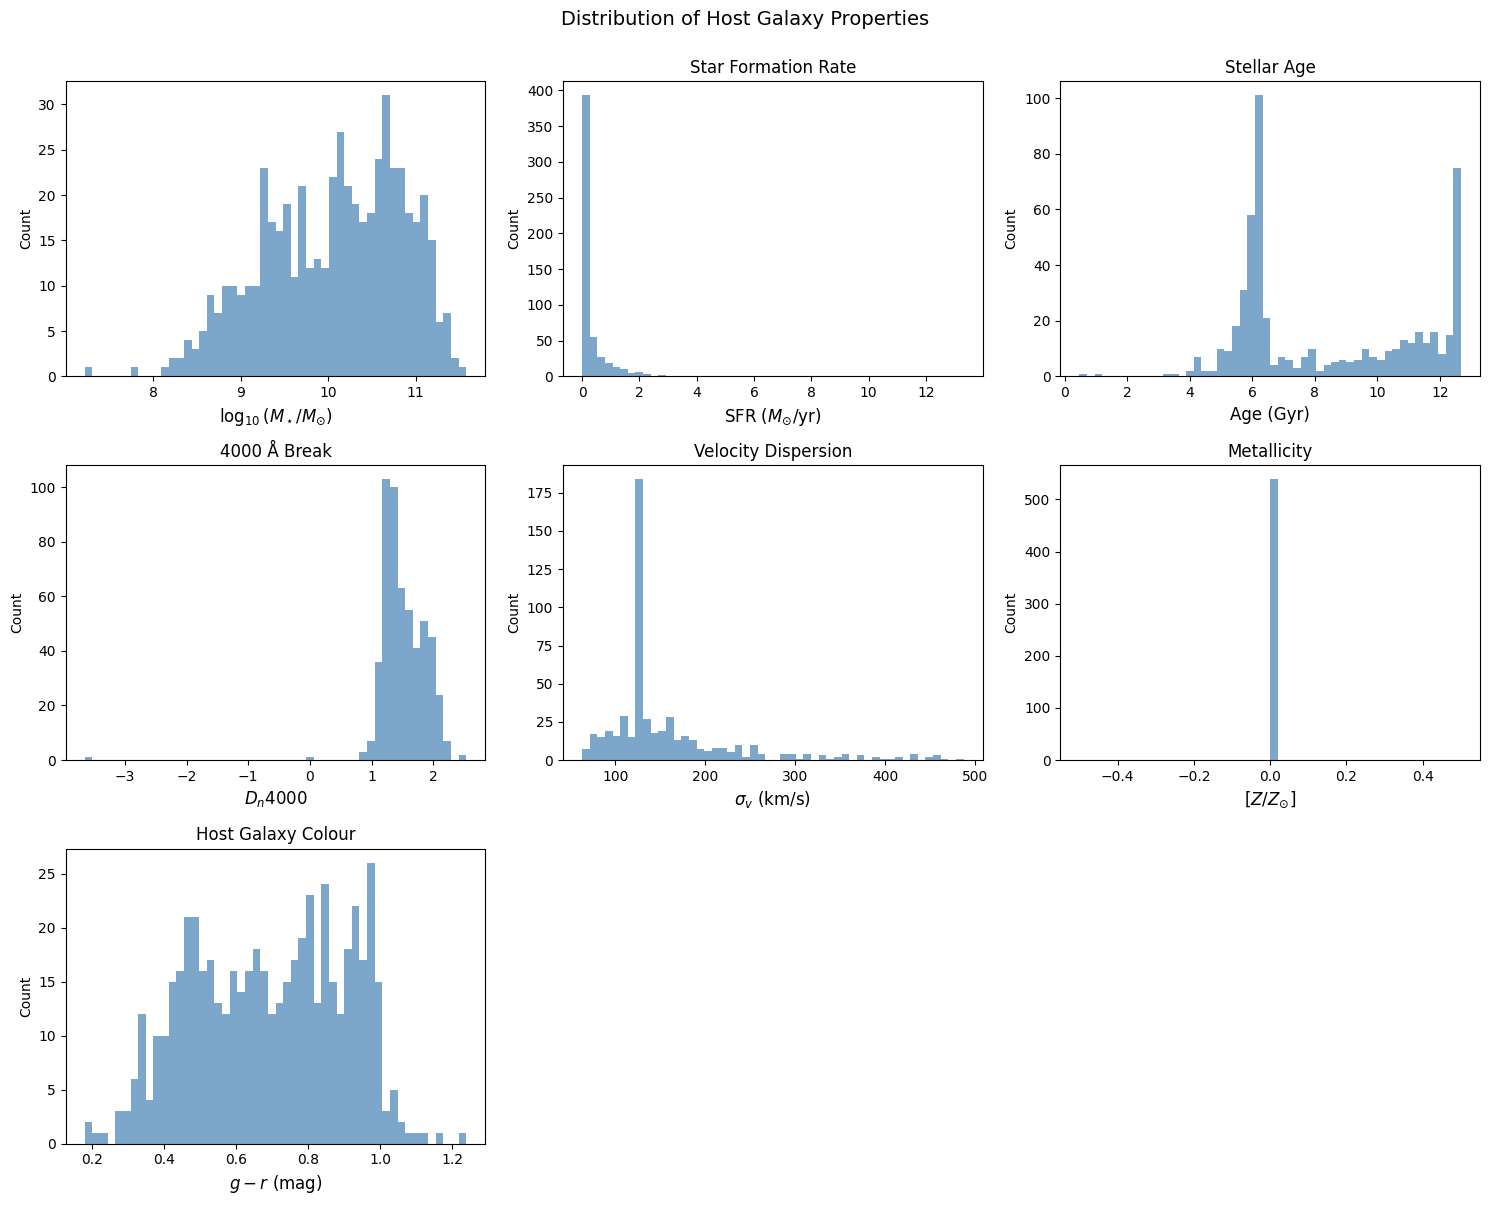

In [3]:
df["DESI_FASTSPEC_g_minus_r"] = df["DESI_FASTSPEC_ABSMAG01_SDSS_G"] - df["DESI_FASTSPEC_ABSMAG01_SDSS_R"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Now Lets Get some Quality Cuts Defined and See What the Final Histograms Looks Like #

In [4]:
print(f"Before cuts: {len(df)}")

mask_sfr = df["DESI_FASTSPEC_SFR"] <= 2.5
print(f"SFR <= 2.5:    {mask_sfr.sum()} keep, {(~mask_sfr).sum()} dropped")
df = df[mask_sfr].reset_index(drop=True)

mask_dn4000 = df["DESI_FASTSPEC_DN4000"] >= 0.5
print(f"DN4000 >= 0.5: {mask_dn4000.sum()} keep, {(~mask_dn4000).sum()} dropped")
df = df[mask_dn4000].reset_index(drop=True)

mask_age = df["DESI_FASTSPEC_AGE"] >= 2
print(f"AGE >= 2 Gyr:  {mask_age.sum()} keep, {(~mask_age).sum()} dropped")
df = df[mask_age].reset_index(drop=True)

print(f"After all cuts: {len(df)}")

Before cuts: 540
SFR <= 2.5:    531 keep, 9 dropped
DN4000 >= 0.5: 529 keep, 2 dropped
AGE >= 2 Gyr:  527 keep, 2 dropped
After all cuts: 527


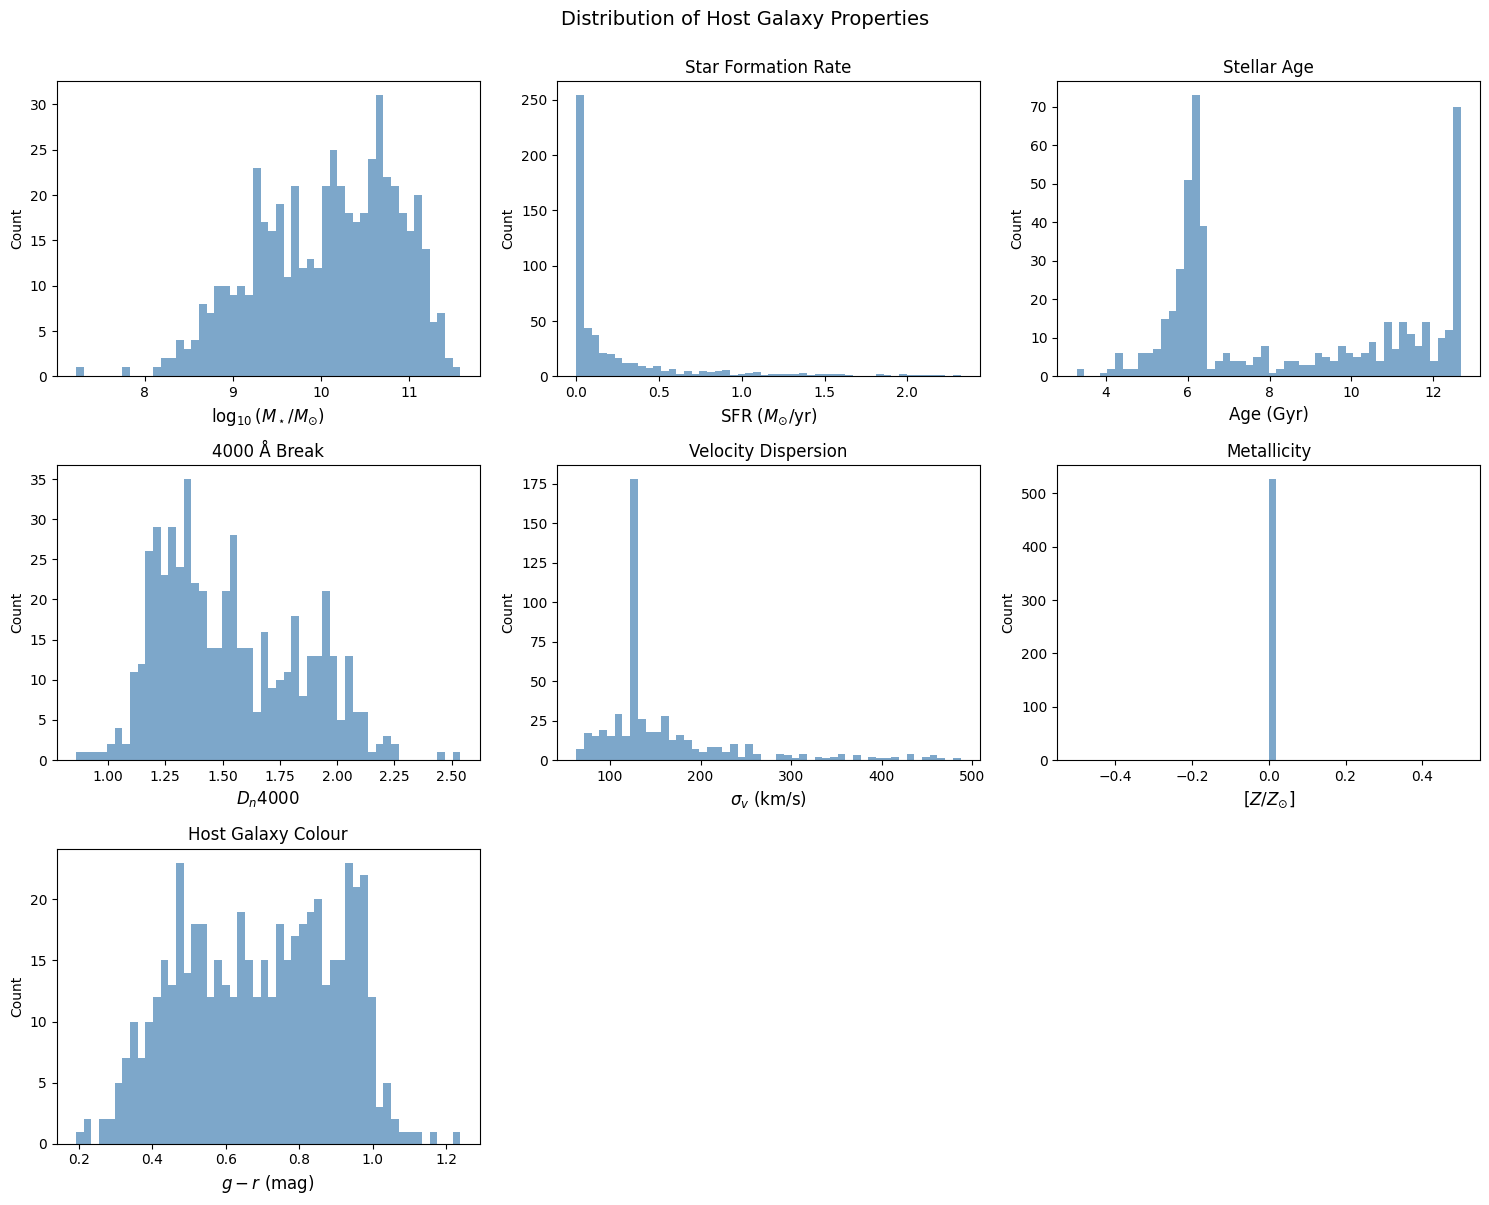

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [6]:
# Define the following global parameters:

alpha = 0.161
beta  = 3.05

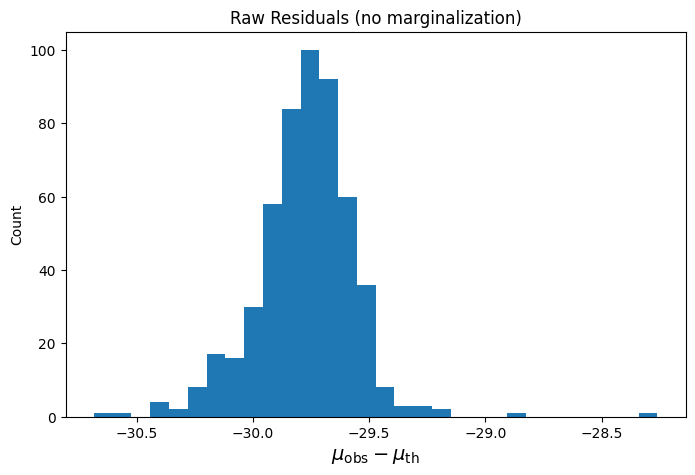

In [7]:
# Calculate the observed distance modulus for each supernova in the dataset: (not mass step corrected by design):
df["ZTF_mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"]

# Define the following cosmology:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Evaluate the cosmology at the ZTF reported redshift. We are using the ZTF redshift instead of DESI
# b/c we're propagating the ZTF uncertainty and we want to keep everything in the same data set. 

mu_th = cosmo.distmod(df["ZTF_redshift"]).value
raw_residuals = df["ZTF_mu_obs"] - mu_th

plt.figure(figsize=(8, 5))
plt.hist(raw_residuals, bins=30)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$", fontsize=14)
plt.ylabel("Count")
plt.title("Raw Residuals (no marginalization)")
plt.show()

# Now lets do the error Propagation from the SALT 2 Model Error #

General Form of the Error Propagation Formula for $y = f(x_1, x_2, \ldots, x_n)$

$
\sigma_y^2 =
\sum_{i=1}^{n}
\left(
\frac{\partial f}{\partial x_i}
\right)^2
\sigma_{x_i}^2
+
\sum_{i \ne j}
2\,
\frac{\partial f}{\partial x_i}
\frac{\partial f}{\partial x_j}
\mathrm{Cov}(x_i, x_j).
$

Using the standard error propagation formula:

$$
\sigma_{\mu,\text{obs}} = \sqrt{
\left(\frac{\partial \mu}{\partial x_0}\right)^2 \sigma_{x_0}^2
+\left(\frac{\partial \mu}{\partial x_1}\right)^2 \sigma_{x_1}^2
+\left(\frac{\partial \mu}{\partial c}\right)^2 \sigma_c^2
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial x_1}\right)\mathrm{Cov}(x_0,x_1)
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_0,c)
+ 2\left(\frac{\partial \mu}{\partial x_1}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_1,c)
}
$$


where:

$
\frac{\partial\mu}{\partial x_0} = \frac{-2.5}{x_0\ln 10}
$

$
\frac{\partial\mu}{\partial x_1} = \alpha
$

$
\frac{\partial\mu}{\partial c} = -\beta
$


Reference: Bevington Ch. 3 Summary



In [8]:
LN10 = np.log(10)

# Partial derivatives of mu_obs w.r.t. SALT2 parameters

dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

df["ZTF_sigma_mu"] = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)


# Negative Log-Likelihood Minimization (Volume-Limited Sample - Always Remember to Volume Limit)

Since $\sigma_{\mathrm{int}}$ is a free parameter, we minimize the
negative log likelihood instead of plain $\chi^2$:

$-2\ln\mathcal{L} = \sum_i \left[\frac{\Delta\mu_i^2}{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2} + \ln\left(\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2\right)\right]$

Please see appendix of this notebook for further explanation

In [9]:
# Define a volume limited data sample in order to avoid Malmquist bias.
df_vlim = df[df["ZTF_redshift"] < 0.06].copy()


# Define an array of theoretical distance moduli
# as applied to the volume limited sample.
mu_th_vlim = cosmo.distmod(df_vlim["ZTF_redshift"]).value


# DEFINE THE NEGATIVE LOG LIKELIHOOD FUNCTION AS ABOVE
# Function must be defined with a 1-D array of parameters 
# otherwise scipy.optimize.minimize will crash. Can't comma separate values. 
def neg_log_likelihood(params):

    script_M, sigma_int = params 

    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M

    residuals = mu_obs - mu_th_vlim

    return np.sum(residuals**2 / (df_vlim["ZTF_sigma_mu"]**2 + sigma_int**2) + np.log(df_vlim["ZTF_sigma_mu"]**2 + sigma_int**2))


# Note this method requires first guesses so we will get some guesses for 
# Script M as 19.5 (absolute magnitude of SNIa -> will be a different quantitiy as we
# are marginalizing over Mb and the Hubble constant and the reported intrinsic scatter
# for the volume limited sample reported in Ginolin. 
result_vlim = minimize(neg_log_likelihood, [-19.5, 0.15])

print(result_vlim)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -371.98273306431963
        x: [-2.975e+01  2.150e-01]
      nit: 26
      jac: [ 2.289e-05  1.068e-04]
 hess_inv: [[ 1.215e-04 -1.001e-05]
            [-1.001e-05  8.358e-05]]
     nfev: 120
     njev: 40


# Now that We Minimized the Negative Log Likelihood We Will Evaluate $\chi^2$ for the Volume Limited Sample of Our Data #

In [10]:
scriptM_vlim, sigma_int_vlim = result_vlim.x
print(f"script-M from Volume Limited Sample  = " + str(scriptM_vlim))
print(f"sigma_int = " + str(sigma_int_vlim))

df_vlim["residual"] = (-2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - scriptM_vlim) - mu_th_vlim
df_vlim["sigma_total"] = np.sqrt(df_vlim["ZTF_sigma_mu"]**2 + sigma_int_vlim**2)

chi2 = np.sum(df_vlim["residual"]**2 / df_vlim["sigma_total"]**2)
print(f"chi2/dof = {chi2 / (len(df_vlim) - 2):.2f}")

script-M from Volume Limited Sample  = -29.753492987519557
sigma_int = 0.21495457044013286
chi2/dof = 1.05


# Now that We Minimized the Negative Log Likelihood for the Volume Limited Sample We are Ready to compute the Residuals #

/var/folders/71/hv72gkrs7g59ty6664549kjr0000gr/T/ipykernel_49001/2337485234.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(sim_z, mu_th_plot, "r-", label="Theoretical Distance Modulus", color = "orange", linewidth = 5)


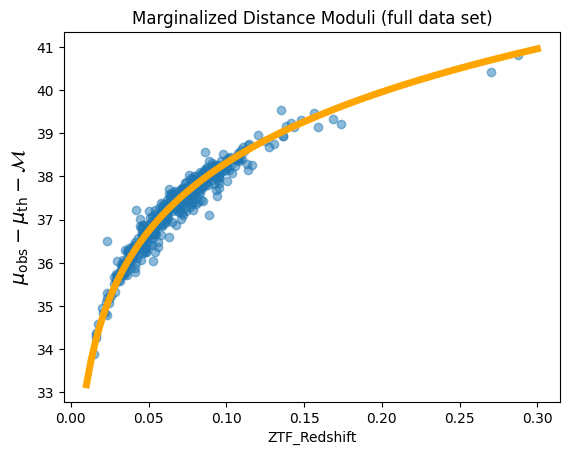

In [11]:
# Note we are applying this script-M to the full data set.
# We are just borrowing scriptM_vlim from the volume limited sample.
# "ZTF_mu_obs" 
marginalized_distance_modulus = df["ZTF_mu_obs"] - scriptM_vlim

# Data necessary froom the Theory Plot
sim_z = np.linspace(0.01, 0.3, 100)
mu_th_plot = cosmo.distmod(sim_z).value


plt.plot(df["ZTF_redshift"], marginalized_distance_modulus, "o", alpha=0.5)
plt.plot(sim_z, mu_th_plot, "r-", label="Theoretical Distance Modulus", color = "orange", linewidth = 5)
plt.xlabel("ZTF_Redshift")
plt.ylabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.title("Marginalized Distance Moduli (full data set)")
plt.show()

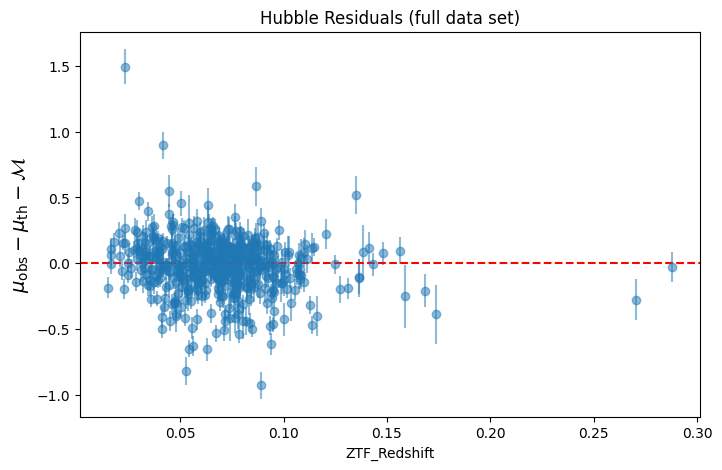

In [12]:
df["residuals"] = df["ZTF_mu_obs"] - cosmo.distmod(df["ZTF_redshift"]).value - scriptM_vlim
plt.figure(figsize=(8, 5))
plt.errorbar(df["ZTF_redshift"], df["residuals"], yerr=df["ZTF_sigma_mu"], fmt="o", alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("ZTF_Redshift")
plt.ylabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.title("Hubble Residuals (full data set)")
plt.show()

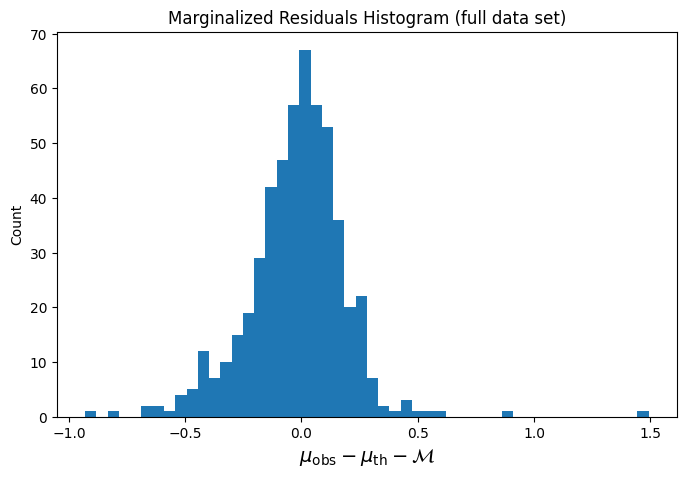

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["residuals"], bins=50)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.ylabel("Count")
plt.title("Marginalized Residuals Histogram (full data set)")
plt.show()


# Now We Will Sigma Clip the Hubble Residuals #

Sigma clipping is a common method for outlier rejection. 

By sigma clipping, we say "anything more than 3 standard deviations from the median is probably not part of the real distribution I care about."




527 SNe before sigma clip
521 SNe after 3σ clipping on Δμ


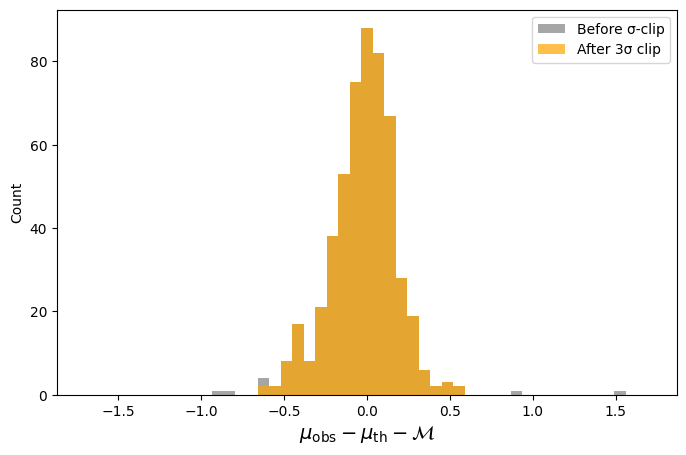

In [14]:
# 3-sigma clip, single iteration
# returns a masked array where the outliers are 
# masked true and all other data points ar emasked false.
# NOTE: we sigma clip one, if we wanted to rebalance the median
# and clip again. Then 
unclipped_residuals = df["residuals"]
clip = sigma_clip(df["residuals"], sigma=3, maxiters=1)
mask_keep = ~clip.mask # retain all other points esides outliers.

print(f"{len(df)} SNe before sigma clip")
df = df.loc[mask_keep]
print(f"{len(df)} SNe after 3σ clipping on Δμ")

bins = np.linspace(-1.7, 1.7, 50)
plt.figure(figsize=(8, 5))
plt.hist(unclipped_residuals, bins=bins, label="Before σ-clip", color="gray", alpha=0.7)
plt.hist(df["residuals"], bins=bins, label="After 3σ clip", color="orange", alpha=0.7)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.ylabel("Count")
plt.legend()
plt.show()

In [15]:
df.to_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv", index=False)